### Final Features

In [4]:
# All samples and features from both V1 and V2
import pandas as pd

# === File paths ===
excel_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"

# === Read sheets ===
df = pd.read_excel(excel_path, sheet_name="Sheet4")

# === Optional: print summary ===
print("✅ Loaded Sheet4 from V1V1 Excel:", df.shape)
print("df Columns:")
print(list(df.columns))

✅ Loaded Sheet4 from V1V1 Excel: (432, 688)
df Columns:
['PID', 'MRN', 'DOB', 'Age', 'Weight_Kg', 'Avg_Weight_Kg', 'Vent_Type', '1st_Time_Start', '12th_Time_Start', 'FileName_V2_1st(V1_Vital_1st)', 'V2_1st_Raw_IsValid', 'FileName_V2_12th(V1_Vital_12th)', 'V2_12th_Raw_IsValid', 'FileName_V1_Waveform_1st', 'V2_1st_IsDuplicate', 'Is_Overlapping', 'Cohort_Source', 'OSI_V2_1st_avg', 'OSI_V2_1st_std', 'OSI_V2_12th_avg', 'OSI_V2_12th_std', 'OSI_mean_TW1', 'OSI_std_TW1', 'OSI_mean_TW2', 'OSI_std_TW2', 'OSI_mean_TW3', 'OSI_std_TW3', 'OSI_mean_TW4', 'OSI_std_TW4', 'OSI_mean_TW5', 'OSI_std_TW5', 'OSI_mean_TW6', 'OSI_std_TW6', 'PIP_mean_TW1', 'PIP_std_TW1', 'PIP_mean_TW2', 'PIP_std_TW2', 'PIP_mean_TW3', 'PIP_std_TW3', 'PIP_mean_TW4', 'PIP_std_TW4', 'PIP_mean_TW5', 'PIP_std_TW5', 'PIP_mean_TW6', 'PIP_std_TW6', 'PEEP_mean_TW1', 'PEEP_std_TW1', 'PEEP_mean_TW2', 'PEEP_std_TW2', 'PEEP_mean_TW3', 'PEEP_std_TW3', 'PEEP_mean_TW4', 'PEEP_std_TW4', 'PEEP_mean_TW5', 'PEEP_std_TW5', 'PEEP_mean_TW6', 'PEEP_std

In [1]:
import pandas as pd

# === Load Excel ===
excel_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"
df = pd.read_excel(excel_path, sheet_name="Sheet4")

# === Define required columns ===
target_col = "OSI_V2_12th_avg"

base_template = [
    "OSI_mean_TW{}", "OSI_std_TW{}", "PIP_mean_TW{}", "PIP_std_TW{}",
    "PEEP_mean_TW{}", "PEEP_std_TW{}", "TV_mean_TW{}(mL/Kg)", "TV_std_TW{}(mL/Kg)",
    "Avg_NegFlowDur_TW{}", "Std_NegFlowDur_TW{}", "Avg_PeakInterval_TW{}", "Std_PeakInterval_TW{}"
]

tw_features = {
    i: [f.format(i) for f in base_template] + [f"w{i}_SubBandEnergy_row{j}" for j in range(1, 17)]
    for i in range(1, 7)
}

required_columns = [target_col] + [col for features in tw_features.values() for col in features]

# === Drop rows with missing values in required columns (make a copy to avoid warnings) ===
filtered_df = df.dropna(subset=required_columns).copy()

# === Compute Age_Year ===
filtered_df["Age_Year"] = (
    (pd.to_datetime(filtered_df["1st_Time_Start"]) - pd.to_datetime(filtered_df["DOB"]))
    .dt.total_seconds() / (365.25 * 24 * 3600)
).round(2)

# === Create Weight_Kg_New: prefer Avg_Weight_Kg unless it's 0 or NaN ===
filtered_df["Weight_Kg_New"] = filtered_df.apply(
    lambda row: row["Weight_Kg"] if pd.isna(row["Avg_Weight_Kg"]) or row["Avg_Weight_Kg"] == 0 else row["Avg_Weight_Kg"],
    axis=1
).round(2)

# === Assign Severity_Label based on OSI_V2_12th_avg ===
def classify_severity(val):
    if val < 7.5:
        return "mild"
    elif val < 12.3:
        return "moderate"
    else:
        return "severe"

filtered_df["Severity_Label"] = filtered_df[target_col].apply(classify_severity)

# === Save first 9 columns + Age_Year + Weight_Kg_New + target_col + Severity_Label ===
filtered_df_first9 = filtered_df.iloc[:, :9].copy()
filtered_df_first9["Age_Year"] = filtered_df["Age_Year"]
filtered_df_first9["Weight_Kg_New"] = filtered_df["Weight_Kg_New"]
filtered_df_first9[target_col] = filtered_df[target_col]
filtered_df_first9["Severity_Label"] = filtered_df["Severity_Label"]

filtered_df_first9.to_csv("filtered_df_first9_columns.csv", index=False)
print("✅ Saved to 'filtered_df_first9_columns.csv', shape:", filtered_df_first9.shape)


✅ Saved to 'filtered_df_first9_columns.csv', shape: (365, 13)


### Unit standardization for OSI, PIP, and PEEP (if Vent_Type is CDGR, then multiply by 1.01972)

In [1]:
import pandas as pd

# === Load the original Excel sheet ===
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# === Identify OSI, PIP, and PEEP columns ===
columns_to_scale = [col for col in df.columns if any(key in col for key in ["OSI", "PIP", "PEEP"])]

# === Create a copy of the DataFrame to modify ===
df_scaled = df.copy()

# === Apply scaling factor to CDGR ventilator rows only ===
scale_factor = 1.01972
cdgr_mask = df_scaled["Vent_Type"] == "CDGR"

df_scaled.loc[cdgr_mask, columns_to_scale] = (
    df_scaled.loc[cdgr_mask, columns_to_scale] * scale_factor
)

# === Save to Sheet2 ===
with pd.ExcelWriter(file_path, mode="a", if_sheet_exists="replace") as writer:
    df_scaled.to_excel(writer, sheet_name="Sheet2", index=False)

print("✅ Scaling complete. Modified data saved to Sheet2.")


✅ Scaling complete. Modified data saved to Sheet2.


##### mRMR for Flow 4-level DTCWPT Sub-energies V.S. 12th-hour OSI

In [4]:
# # Top 2

# import pandas as pd
# import numpy as np
# from sklearn.feature_selection import mutual_info_regression

# # Load the Excel sheet
# df_combined = pd.read_excel(
#     '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx',
#     sheet_name='Sheet2'
# )

# target_column = "OSI_V2_12th_avg"

# # Store results
# results = []

# # Loop through time windows w1 to w6
# for w in range(1, 7):
#     # Construct feature names for current window
#     energy_cols = [f"w{w}_SubBandEnergy_row{i}" for i in range(1, 17)]
    
#     # Check columns exist
#     missing_cols = [col for col in energy_cols + [target_column] if col not in df_combined.columns]
#     if missing_cols:
#         print(f"⚠️ Skipping w{w} due to missing columns: {missing_cols}")
#         continue

#     # Subset data
#     X = df_combined[energy_cols]
#     y = df_combined[target_column]
#     combined_data = pd.concat([X, y], axis=1).dropna()
#     X = combined_data[energy_cols]
#     y = combined_data[target_column]

#     # Mutual Information
#     mi_scores = mutual_info_regression(X, y)
#     mi_scores_normalized = mi_scores / np.max(mi_scores) if np.max(mi_scores) > 0 else mi_scores

#     # Redundancy (mean absolute correlation with other features)
#     corr_matrix = combined_data[energy_cols].corr().abs()
#     redundancy_scores = corr_matrix.mean(axis=1).values

#     # mRMR score = relevance - redundancy
#     mrmr_scores = mi_scores_normalized - redundancy_scores

#     # Get top 2 features
#     top_indices = np.argsort(mrmr_scores)[-2:][::-1]
#     top_features = [energy_cols[i] for i in top_indices]
    
#     print(f"\n✅ Top mRMR features for w{w}:")
#     for i, feat in enumerate(top_features):
#         print(f"{i+1}. {feat} (mRMR score = {mrmr_scores[top_indices[i]]:.4f})")

#     # Save results
#     results.append({
#         'Window': f'w{w}',
#         'Top1_Feature': top_features[0],
#         'Top1_Score': mrmr_scores[top_indices[0]],
#         'Top2_Feature': top_features[1],
#         'Top2_Score': mrmr_scores[top_indices[1]]
#     })

# # Optional: save results to DataFrame
# mRMR_results = pd.DataFrame(results)
# mRMR_results.to_csv("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/mRMR_results.csv", index=False)
# print("\nSummary of top mRMR features per window:")
# print(mRMR_results)



✅ Top mRMR features for w1:
1. w1_SubBandEnergy_row1 (mRMR score = 0.3581)
2. w1_SubBandEnergy_row6 (mRMR score = -0.1763)

✅ Top mRMR features for w2:
1. w2_SubBandEnergy_row9 (mRMR score = 0.0825)
2. w2_SubBandEnergy_row1 (mRMR score = -0.0884)

✅ Top mRMR features for w3:
1. w3_SubBandEnergy_row9 (mRMR score = 0.0729)
2. w3_SubBandEnergy_row13 (mRMR score = -0.0546)

✅ Top mRMR features for w4:
1. w4_SubBandEnergy_row1 (mRMR score = 0.6367)
2. w4_SubBandEnergy_row2 (mRMR score = 0.2633)

✅ Top mRMR features for w5:
1. w5_SubBandEnergy_row2 (mRMR score = 0.2658)
2. w5_SubBandEnergy_row1 (mRMR score = 0.2430)

✅ Top mRMR features for w6:
1. w6_SubBandEnergy_row2 (mRMR score = 0.1920)
2. w6_SubBandEnergy_row1 (mRMR score = 0.1398)

Summary of top mRMR features per window:
  Window           Top1_Feature  Top1_Score            Top2_Feature  \
0     w1  w1_SubBandEnergy_row1    0.358113   w1_SubBandEnergy_row6   
1     w2  w2_SubBandEnergy_row9    0.082454   w2_SubBandEnergy_row1   
2  

In [1]:
# All
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression

# Load the Excel sheet
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx',
    sheet_name='Sheet3'
)

target_column = "OSI_V2_12th_avg"
all_results = []

# Loop through time windows w1 to w6
for w in range(1, 7):
    energy_cols = [f"w{w}_SubBandEnergy_row{i}" for i in range(1, 17)]

    # Check if columns exist
    missing_cols = [col for col in energy_cols + [target_column] if col not in df_combined.columns]
    if missing_cols:
        print(f"⚠️ Skipping w{w} due to missing columns: {missing_cols}")
        continue

    # Drop NaNs
    X = df_combined[energy_cols]
    y = df_combined[target_column]
    combined = pd.concat([X, y], axis=1).dropna()
    X = combined[energy_cols]
    y = combined[target_column]

    # Compute relevance
    mi_scores = mutual_info_regression(X, y)
    mi_scores_normalized = mi_scores / np.max(mi_scores) if np.max(mi_scores) > 0 else mi_scores

    # Compute redundancy
    corr_matrix = X.corr().abs()
    redundancy_scores = corr_matrix.mean(axis=1).values

    # Compute mRMR
    mrmr_scores = mi_scores_normalized - redundancy_scores

    # Store all features
    for i, feat in enumerate(energy_cols):
        all_results.append({
            'Window': f'w{w}',
            'Feature': feat,
            'MI_Score': mi_scores[i],
            'Redundancy': redundancy_scores[i],
            'mRMR_Score': mrmr_scores[i]
        })

    # Print top features
    sorted_indices = np.argsort(mrmr_scores)[::-1]
    print(f"\n✅ Top mRMR features for w{w}:")
    for rank in range(3):  # print top 3 for view
        idx = sorted_indices[rank]
        print(f"{rank + 1}. {energy_cols[idx]} (mRMR = {mrmr_scores[idx]:.4f})")

# Save all to CSV
all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv(
    "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/mRMR_results_all.csv",
    index=False
)
print("\n✅ All mRMR feature scores saved.")



✅ Top mRMR features for w1:
1. w1_SubBandEnergy_row1 (mRMR = 0.3581)
2. w1_SubBandEnergy_row6 (mRMR = -0.1763)
3. w1_SubBandEnergy_row14 (mRMR = -0.4271)

✅ Top mRMR features for w2:
1. w2_SubBandEnergy_row9 (mRMR = 0.0825)
2. w2_SubBandEnergy_row1 (mRMR = -0.0884)
3. w2_SubBandEnergy_row13 (mRMR = -0.1516)

✅ Top mRMR features for w3:
1. w3_SubBandEnergy_row9 (mRMR = 0.0729)
2. w3_SubBandEnergy_row13 (mRMR = -0.0542)
3. w3_SubBandEnergy_row1 (mRMR = -0.0945)

✅ Top mRMR features for w4:
1. w4_SubBandEnergy_row1 (mRMR = 0.6367)
2. w4_SubBandEnergy_row2 (mRMR = 0.2633)
3. w4_SubBandEnergy_row5 (mRMR = -0.3436)

✅ Top mRMR features for w5:
1. w5_SubBandEnergy_row2 (mRMR = 0.2658)
2. w5_SubBandEnergy_row1 (mRMR = 0.2432)
3. w5_SubBandEnergy_row9 (mRMR = -0.2499)

✅ Top mRMR features for w6:
1. w6_SubBandEnergy_row2 (mRMR = 0.1920)
2. w6_SubBandEnergy_row1 (mRMR = 0.1398)
3. w6_SubBandEnergy_row5 (mRMR = -0.4214)

✅ All mRMR feature scores saved.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# Load data
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet2')

# Target column
target_column = "OSI_V2_12th_avg"

# Time windows
time_windows = [f"w{i}" for i in range(1, 7)]

# Output folder for saving plots
output_folder = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk_V2/DTCWPT_and_mRMR"

# Loop through each time window
for tw in time_windows:
    # Sub-band energy features for this time window
    subband_energy_columns = [f"{tw}_SubBandEnergy_row{i}" for i in range(1, 17)]

    # Ensure columns exist
    valid_columns = [col for col in subband_energy_columns if col in df.columns]
    if len(valid_columns) < 10:  # Skip if not enough features
        print(f"⏭️ Skipping {tw}: too few valid columns.")
        continue

    # Drop rows with missing values
    combined = df[valid_columns + [target_column]].dropna()
    if combined.empty:
        print(f"⚠️ Skipping {tw}: no complete rows.")
        continue

    X = combined[valid_columns]
    y = combined[target_column]

    # Calculate Mutual Information (Relevance)
    mi_scores = mutual_info_regression(X, y)
    mi_scores_normalized = mi_scores / np.max(mi_scores)

    # Calculate Redundancy (mean of pairwise correlations)
    corr_matrix = X.corr().values
    redundancy_scores = np.mean(np.abs(corr_matrix), axis=1)

    # mRMR score = Relevance - Redundancy
    mrmr_scores = mi_scores_normalized - redundancy_scores

    # Plot
    plt.figure(figsize=(18, 8))
    x_labels = valid_columns

    # Bar for Relevance
    plt.bar(x_labels, mi_scores_normalized, label="Relevance (Normalized MI)", color="skyblue")
    # Bar for Redundancy (negative)
    plt.bar(x_labels, -redundancy_scores, label="Redundancy (Mean Corr)", color="salmon")
    # Line plot for mRMR
    plt.plot(x_labels, mrmr_scores, label="mRMR Score", color="green", linestyle="--", marker="o", linewidth=3)

    # Annotate top 2 features
    top_indices = np.argsort(mrmr_scores)[-2:][::-1]
    for i in top_indices:
        score = mrmr_scores[i]
        plt.text(i, score + 0.05, f"{score:.2f} (#{top_indices.tolist().index(i)+1})",
                 color="green", fontsize=14, ha="center", va="bottom")

    # Labels
    plt.title(f"Relevance, Redundancy, mRMR — {tw}", fontsize=22)
    plt.xlabel("Sub-band Features", fontsize=18)
    plt.ylabel("Score", fontsize=18)
    plt.xticks(rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.axhline(0, color='black', linestyle='--')

    # Legend
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper right', fontsize=14)

    # Layout and Save
    plt.tight_layout()
    plt.savefig(f"{output_folder}/mRMR_{tw}.png", dpi=300)
    plt.savefig(f"{output_folder}/mRMR_{tw}.pdf", bbox_inches="tight")
    plt.close()

    print(f"✅ Saved plots for {tw}")

print("🎉 All time windows processed.")


✅ Saved plots for w1
✅ Saved plots for w2
✅ Saved plots for w3
✅ Saved plots for w4
✅ Saved plots for w5
✅ Saved plots for w6
🎉 All time windows processed.


In [2]:
# ### Upsampling the Vital signals as the same sampling rate as Waveform signals for V1
# import os
# import pandas as pd

# # === Input Paths ===
# waveform_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st"
# vital_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st"

# # === Output Path ===
# upsampled_dir = os.path.expanduser("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st")
# os.makedirs(upsampled_dir, exist_ok=True)

# # === Index all vital files by prefix ===
# vital_files = {
#     "_".join(f.split("_")[:3]): os.path.join(vital_dir, f)
#     for f in os.listdir(vital_dir)
#     if f.endswith(".csv")
# }

# # === Process waveform files ===
# for wf_file in os.listdir(waveform_dir):
#     if not wf_file.endswith(".csv"):
#         continue

#     wf_prefix = "_".join(wf_file.split("_")[:3])
#     wf_path = os.path.join(waveform_dir, wf_file)

#     if wf_prefix not in vital_files:
#         print(f"❌ No matching vital file for: {wf_file}")
#         continue

#     vt_path = vital_files[wf_prefix]

#     df_wf = pd.read_csv(wf_path)
#     df_vt = pd.read_csv(vt_path)

#     if "Time" not in df_wf.columns or "Relative Time (sec)" not in df_wf.columns:
#         print(f"⚠️ Waveform file {wf_file} missing required columns.")
#         continue

#     if "Relative Time (sec)" not in df_vt.columns:
#         print(f"⚠️ Vital file {vt_path} missing 'Relative Time (sec)' column.")
#         continue

#     df_wf["Time"] = pd.to_datetime(df_wf["Time"])
#     wf_deltas = df_wf["Time"].diff().dt.total_seconds().dropna()
#     if wf_deltas.empty:
#         print(f"⚠️ Could not compute sampling rate for waveform file {wf_file}")
#         continue

#     wf_sr = round(1.0 / wf_deltas.mean())
#     print(f"✅ {wf_file}: Waveform SR ≈ {wf_sr} Hz")

#     # Upsample vital using its own Relative Time (not matching waveform)
#     df_vt = df_vt.sort_values("Relative Time (sec)").reset_index(drop=True)
#     upsampled_rows = []

#     for i in range(len(df_vt) - 1):
#         t0 = df_vt.loc[i, "Relative Time (sec)"]
#         t1 = df_vt.loc[i + 1, "Relative Time (sec)"]
#         duration = t1 - t0
#         num_samples = max(1, int(round(duration * wf_sr)))

#         repeated_rows = pd.DataFrame([df_vt.loc[i].values] * num_samples, columns=df_vt.columns)
#         repeated_rows["Relative Time (sec)"] = [t0 + j / wf_sr for j in range(num_samples)]
#         upsampled_rows.append(repeated_rows)

#     # Handle final row
#     last_t = df_vt.iloc[-1]["Relative Time (sec)"]
#     repeated_last = pd.DataFrame([df_vt.iloc[-1].values] * wf_sr, columns=df_vt.columns)
#     repeated_last["Relative Time (sec)"] = [last_t + j / wf_sr for j in range(wf_sr)]
#     upsampled_rows.append(repeated_last)

#     if not upsampled_rows:
#         print(f"⚠️ No upsampled rows created for {wf_file}")
#         continue

#     df_vt_upsampled = pd.concat(upsampled_rows, ignore_index=True)

#     # Save
#     output_path = os.path.join(upsampled_dir, f"{wf_prefix}_Vital_1st.csv")
#     df_vt_upsampled.to_csv(output_path, index=False)
#     print(f"✅ Saved upsampled vital file: {output_path}")

#     # break   # For demo run


❌ No matching vital file for: 867410_20231226_18_Waveform_1st.csv
✅ 1198474_20240501_01_Waveform_1st.csv: Waveform SR ≈ 97 Hz
✅ Saved upsampled vital file: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st/1198474_20240501_01_Vital_1st.csv
✅ 1288_20231201_11_Waveform_1st.csv: Waveform SR ≈ 96 Hz
✅ Saved upsampled vital file: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st/1288_20231201_11_Vital_1st.csv
✅ 354894_20240427_11_Waveform_1st.csv: Waveform SR ≈ 97 Hz
✅ Saved upsampled vital file: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st/354894_20240427_11_Vi

Using device: cuda

✅ Processing 1370607_20240831_00_V2_1st_Raw.csv | Signal: CAPSULE_AVEAA_VITAL_1189


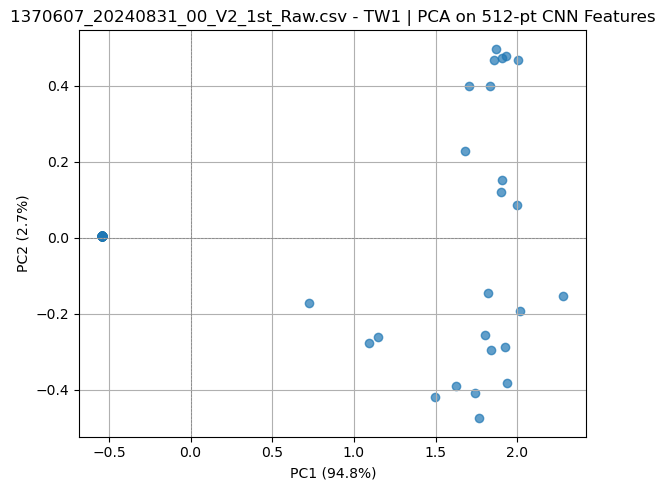

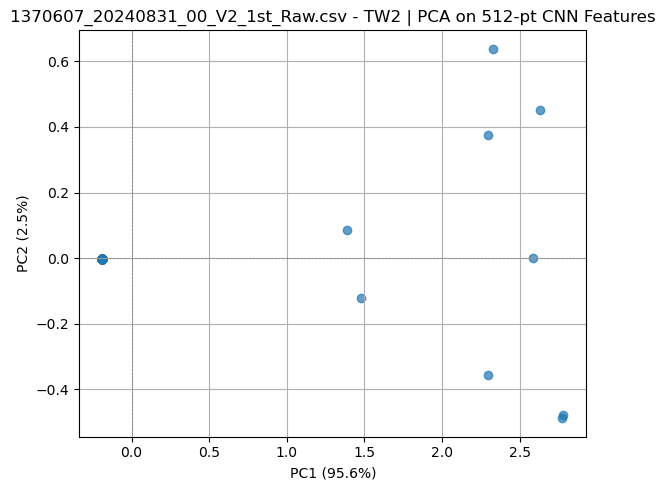

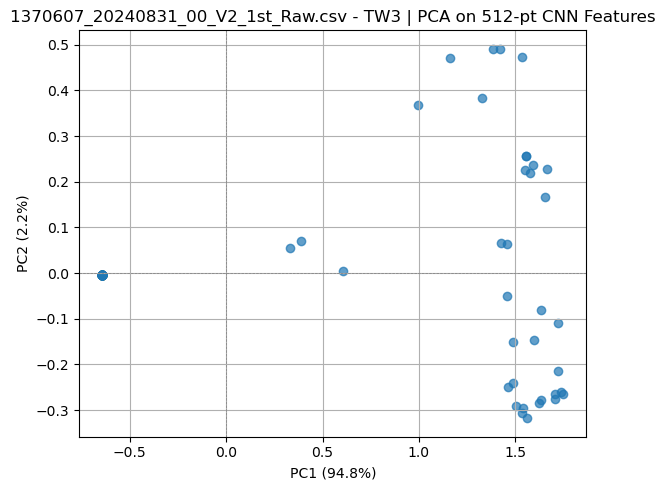

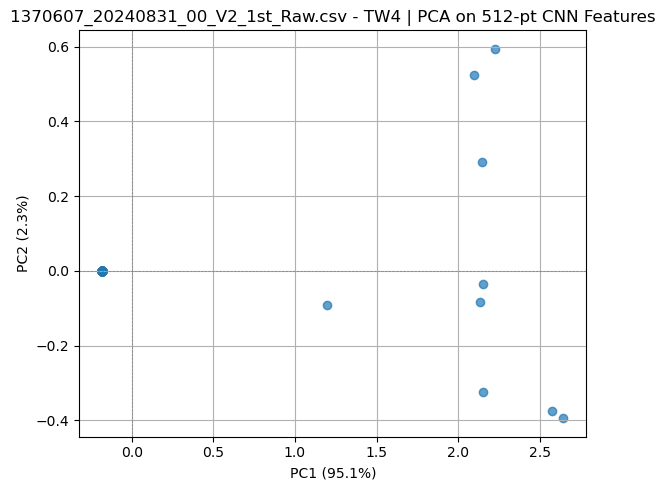

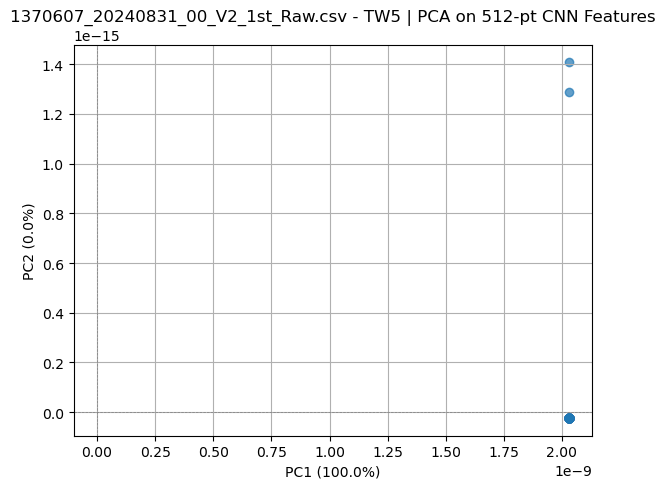

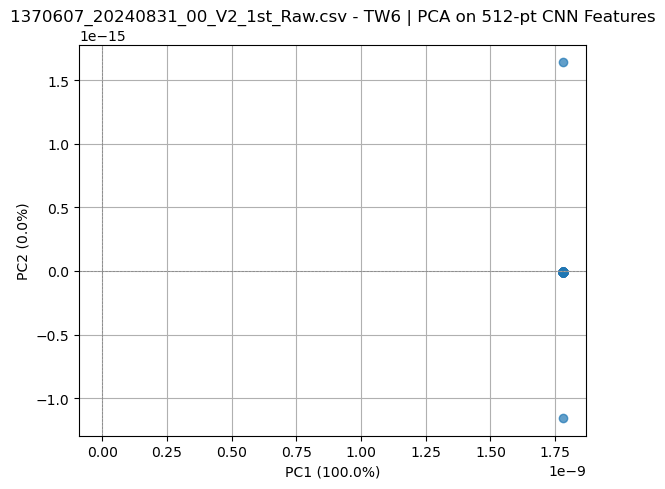

In [1]:
### Convolutional features

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Path and signal name
## V1
# signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st"
# signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st"

# === Signal names
# signal_candidates = ["AVEA - PIP", "CDGR - PIP", "SVU - PIP"]
# signal_candidates = ["AVEA - PEEP", "CDGR - PEEP", "SVU - PEEP"]
# signal_candidates = ["TV (mL/Kg)"]
# signal_candidates = ["CDGR - Flow", "AVEA - Air Flow Wave", "SVU - Flow"]

## V2
signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st"

# signal_candidates = ["CAPSULE_AVEAA_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_MAQUETC_VITAL_1414"]
signal_candidates = ["CAPSULE_AVEAA_VITAL_1189", "CAPSULE_DRAGERMEDIBUS_VITAL_1189", "CAPSULE_MAQUETC_VITAL_1189"]
# signal_candidates = ["TV (mL/Kg)"]
# signal_candidates = ["CAPSULE_AVEAA_WAVE_52911", "CAPSULE_DRAGERMEDIBUS_WAVE_118", "MAQUET_CAPSULE_AIRWAY_FLOW_WAVE"]

# === Unit conversion
conversion_signals = {
    "CDGR - PIP", "CDGR - PEEP",
    "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_1189"
}
conversion_factor = 1.01972

# === Parameters
chunk_length = 512  # 👈 Set this to 1024 or other length if needed
stride = chunk_length  # Non-overlapping chunks

# === CNN Model Definition
class SimpleCNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x.view(x.size(0), -1)

# === Process each file
for fname in os.listdir(signal_dir):
    if not fname.endswith(".csv"):
        continue

    df = pd.read_csv(os.path.join(signal_dir, fname))
    signal_name = next((col for col in signal_candidates if col in df.columns and df[col].notna().any()), None)
    if signal_name is None:
        print(f"❌ No valid signal in {fname}")
        continue

    if signal_name in conversion_signals:
        df[signal_name] *= conversion_factor

    print(f"\n✅ Processing {fname} | Signal: {signal_name}")

    # === Loop through each Time Window
    for tw in range(1, 7):
        df_tw = df[df['Tumbling_window'] == tw]
        if df_tw.empty or signal_name not in df_tw.columns:
            continue

        raw_signal = df_tw[signal_name].dropna().values.astype(np.float32)
        if len(raw_signal) < chunk_length:
            continue

        cnn_features = []
        model = SimpleCNN1D().to(device)

        for start in range(0, len(raw_signal) - chunk_length + 1, stride):
            segment = raw_signal[start:start + chunk_length]
            segment = (segment - segment.mean()) / (segment.std() + 1e-6)
            tensor = torch.tensor(segment).view(1, 1, -1).float().to(device)

            with torch.no_grad():
                feature = model(tensor).cpu().numpy().flatten()
                cnn_features.append(feature)

        if len(cnn_features) < 2:
            print(f"⚠️ Not enough segments in {fname} TW{tw} for PCA")
            continue

        # === PCA
        cnn_features = np.array(cnn_features)
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(cnn_features)

        # === Plot
        plt.figure(figsize=(6, 5))
        plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
        plt.title(f"{fname} - TW{tw} | PCA on {chunk_length}-pt CNN Features")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    break  # remove to process all files


Using device: cuda

✅ Processing 522290_20240606_12_Vital_1st.csv | Signal: CDGR - PIP


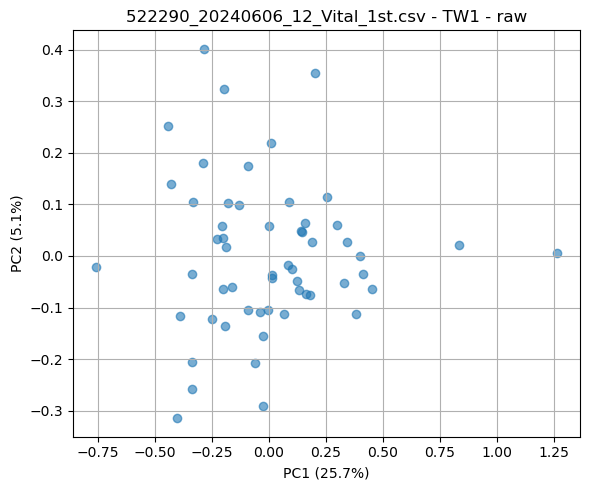

Explained variance for raw - TW1: PC1 = 0.2569, PC2 = 0.0505


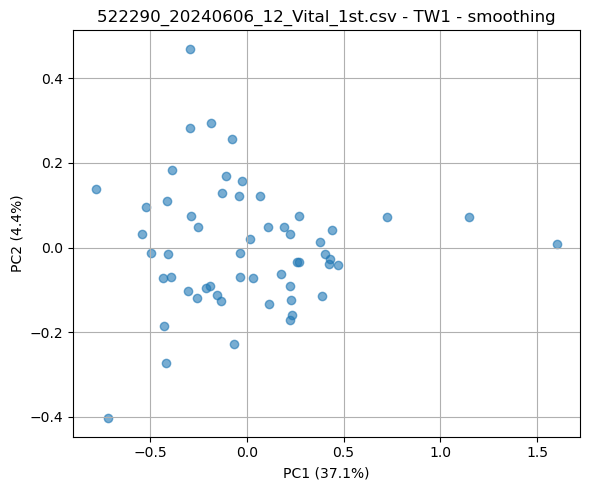

Explained variance for smoothing - TW1: PC1 = 0.3707, PC2 = 0.0441


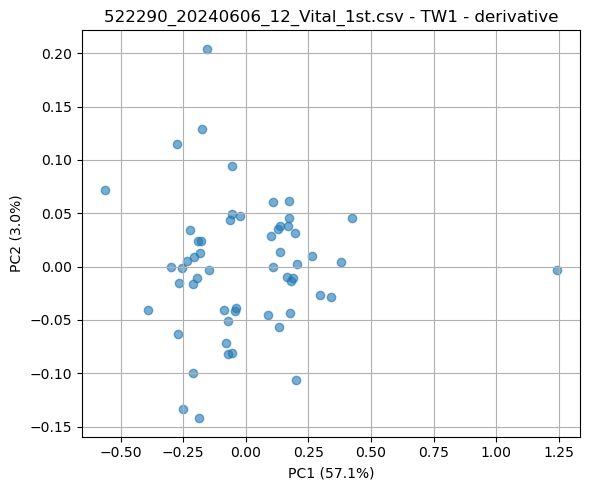

Explained variance for derivative - TW1: PC1 = 0.5711, PC2 = 0.0302


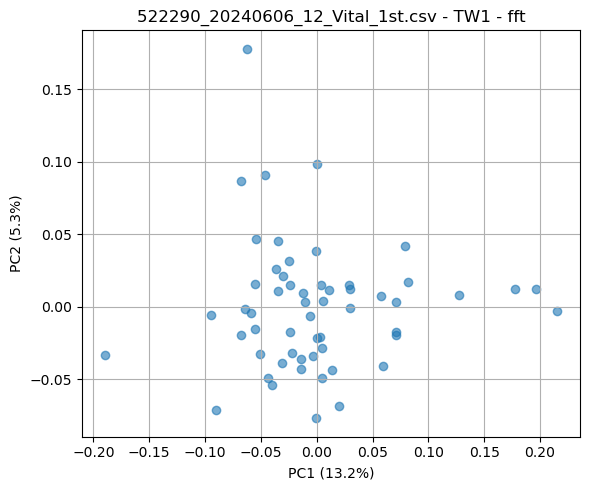

Explained variance for fft - TW1: PC1 = 0.1323, PC2 = 0.0528


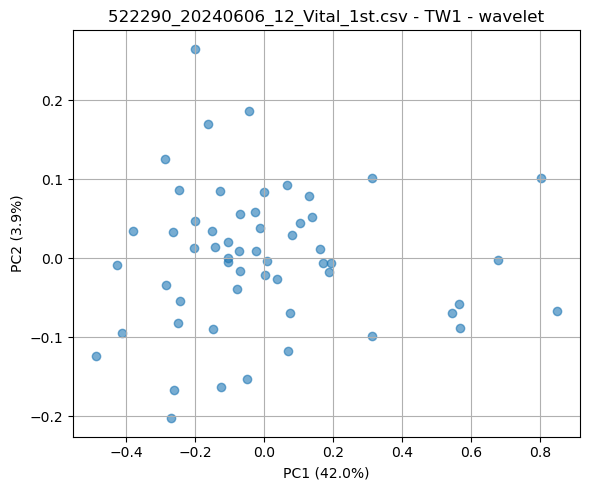

Explained variance for wavelet - TW1: PC1 = 0.4205, PC2 = 0.0391


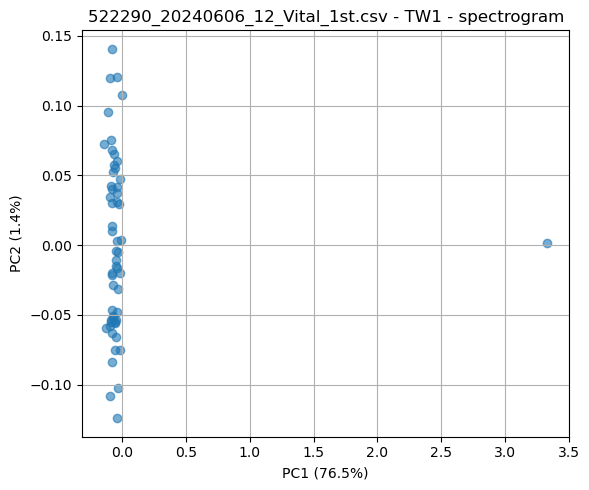

Explained variance for spectrogram - TW1: PC1 = 0.7645, PC2 = 0.0144


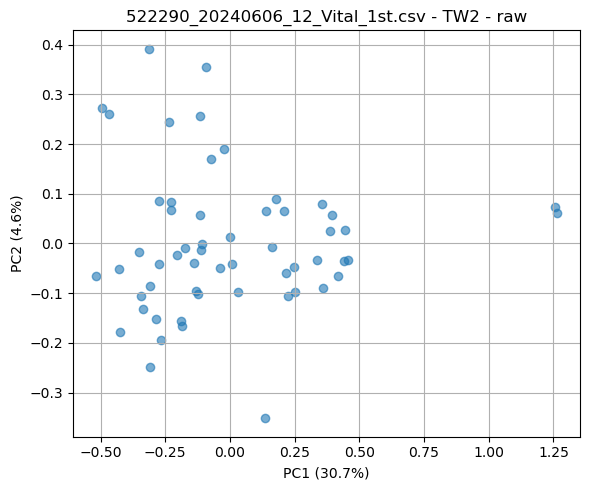

Explained variance for raw - TW2: PC1 = 0.3069, PC2 = 0.0463


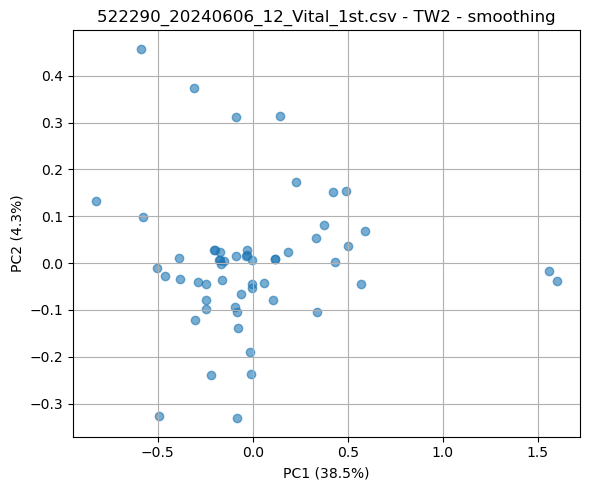

Explained variance for smoothing - TW2: PC1 = 0.3854, PC2 = 0.0433


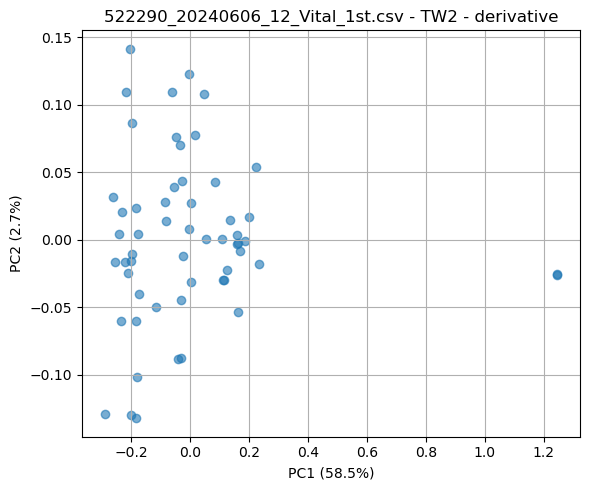

Explained variance for derivative - TW2: PC1 = 0.5845, PC2 = 0.0271


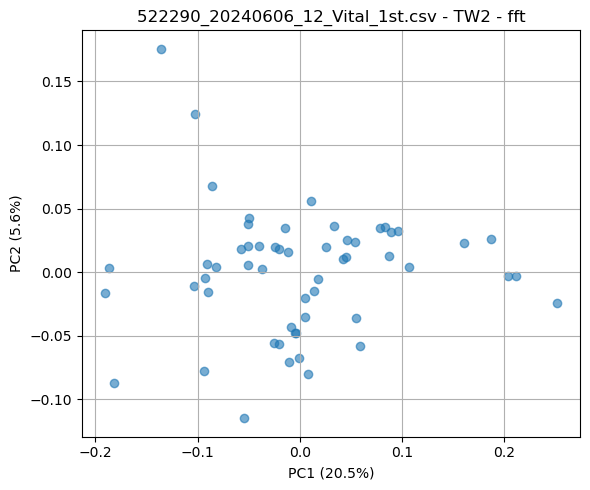

Explained variance for fft - TW2: PC1 = 0.2049, PC2 = 0.0556


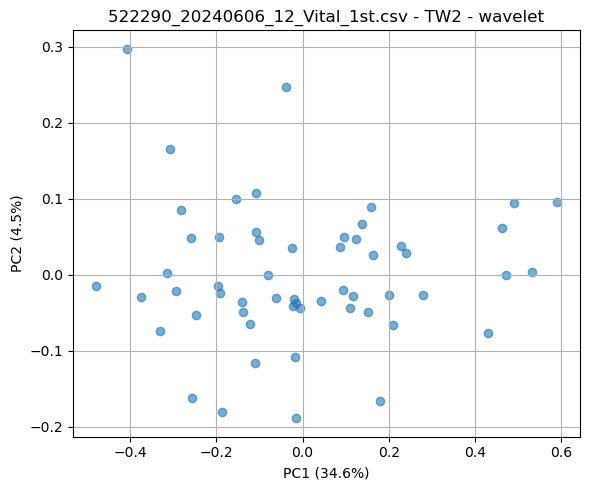

Explained variance for wavelet - TW2: PC1 = 0.3462, PC2 = 0.0455


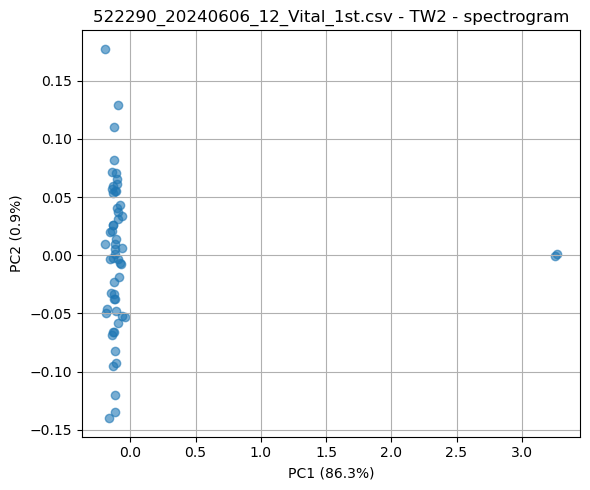

Explained variance for spectrogram - TW2: PC1 = 0.8632, PC2 = 0.0087


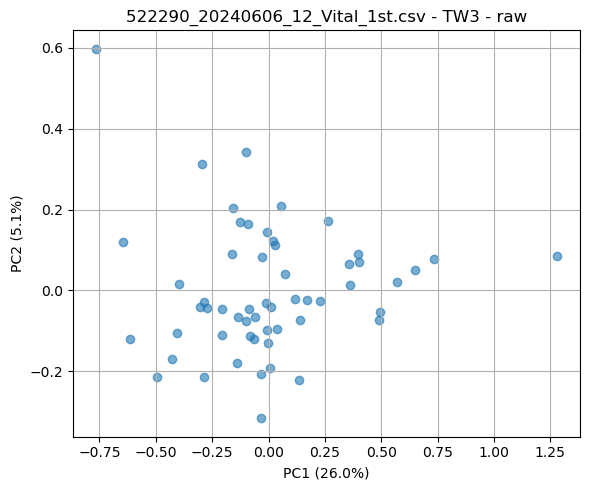

Explained variance for raw - TW3: PC1 = 0.2602, PC2 = 0.0513


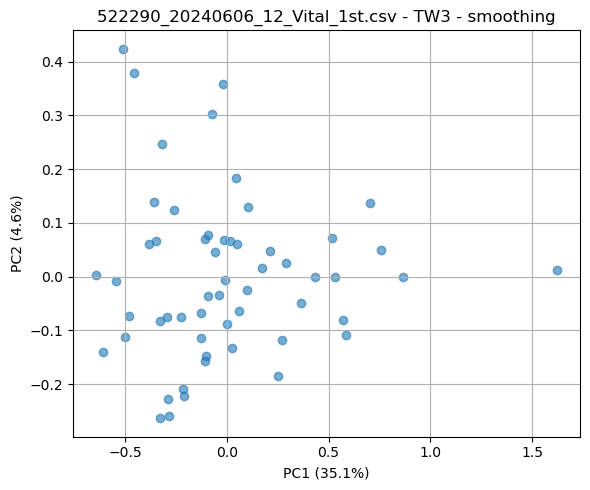

Explained variance for smoothing - TW3: PC1 = 0.3508, PC2 = 0.0459


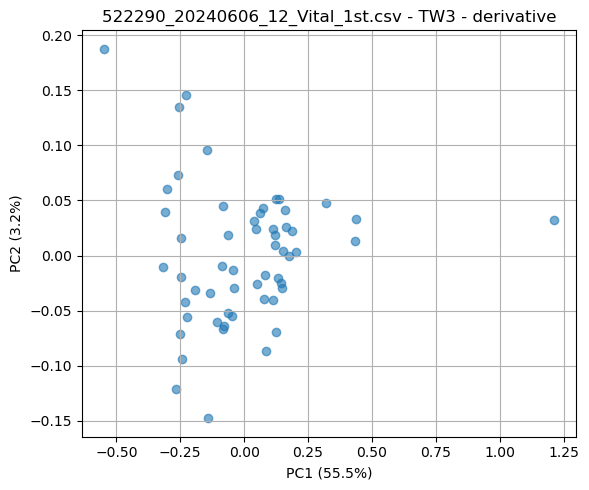

Explained variance for derivative - TW3: PC1 = 0.5546, PC2 = 0.0320


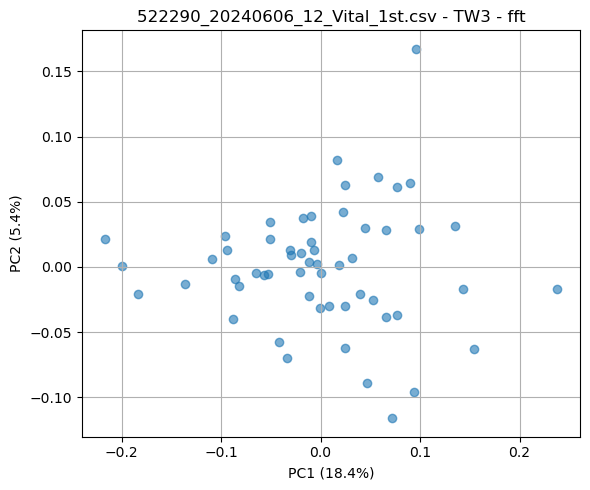

Explained variance for fft - TW3: PC1 = 0.1838, PC2 = 0.0539


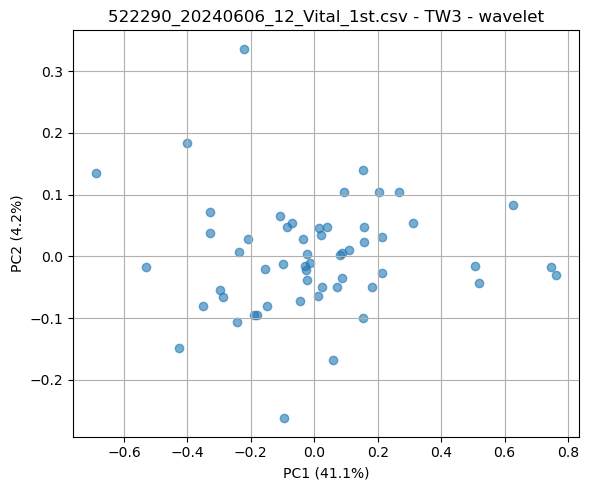

Explained variance for wavelet - TW3: PC1 = 0.4114, PC2 = 0.0417


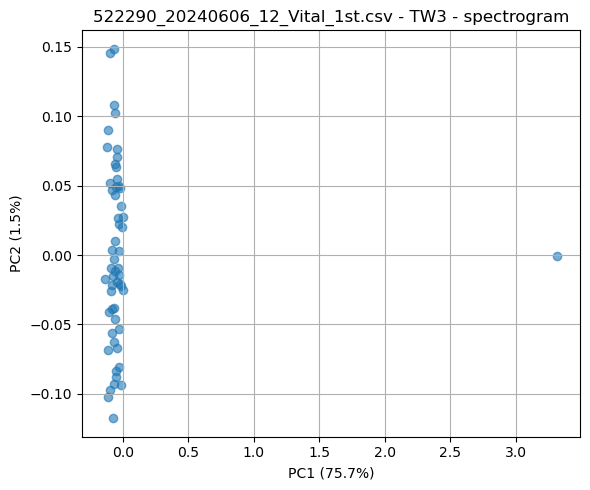

Explained variance for spectrogram - TW3: PC1 = 0.7570, PC2 = 0.0149


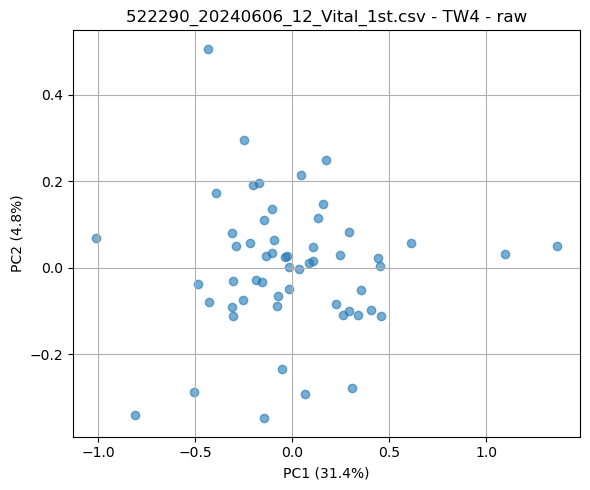

Explained variance for raw - TW4: PC1 = 0.3139, PC2 = 0.0481


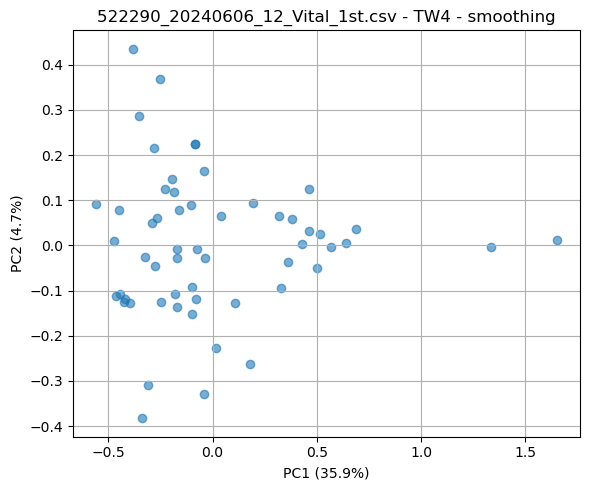

Explained variance for smoothing - TW4: PC1 = 0.3594, PC2 = 0.0473


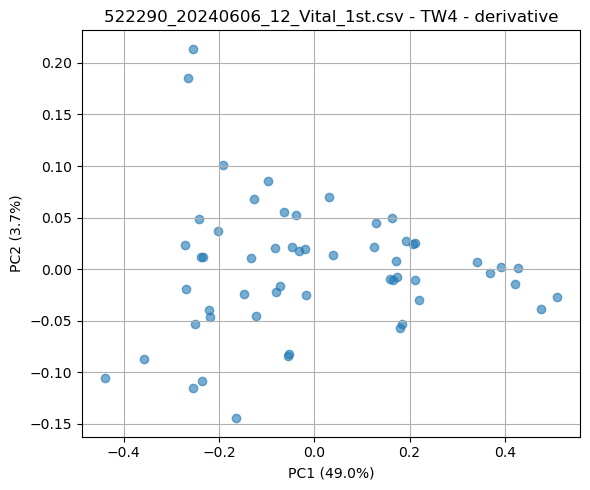

Explained variance for derivative - TW4: PC1 = 0.4902, PC2 = 0.0371


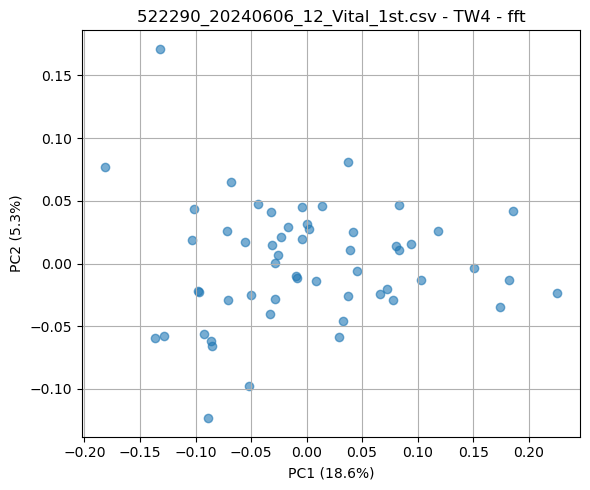

Explained variance for fft - TW4: PC1 = 0.1863, PC2 = 0.0532


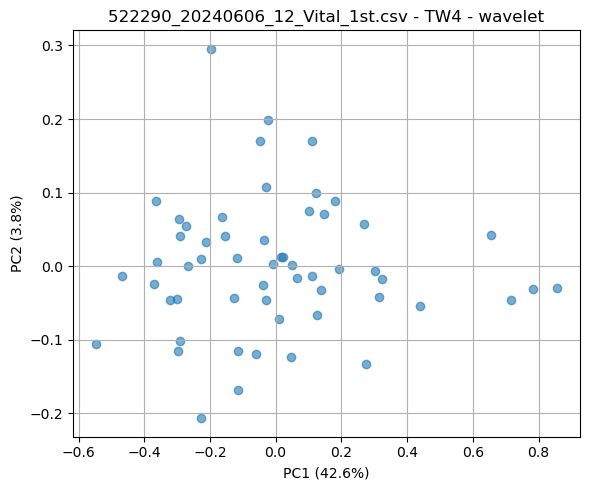

Explained variance for wavelet - TW4: PC1 = 0.4263, PC2 = 0.0383


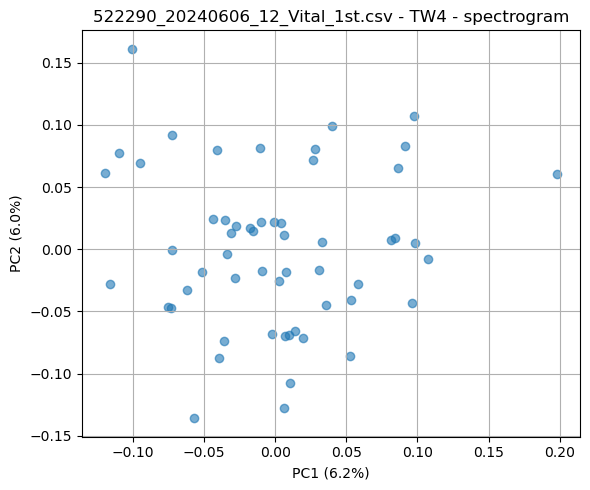

Explained variance for spectrogram - TW4: PC1 = 0.0621, PC2 = 0.0597


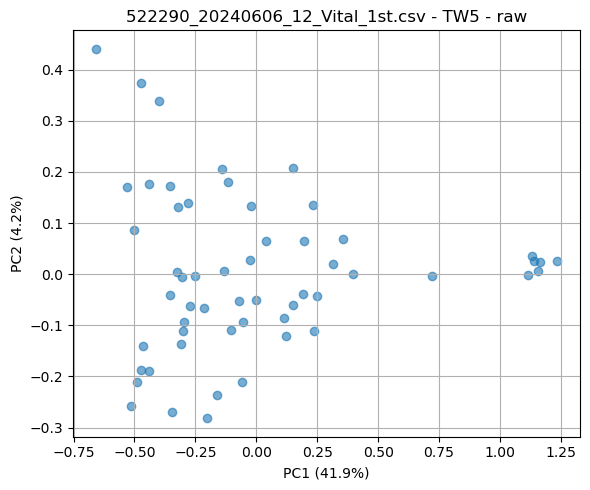

Explained variance for raw - TW5: PC1 = 0.4188, PC2 = 0.0418


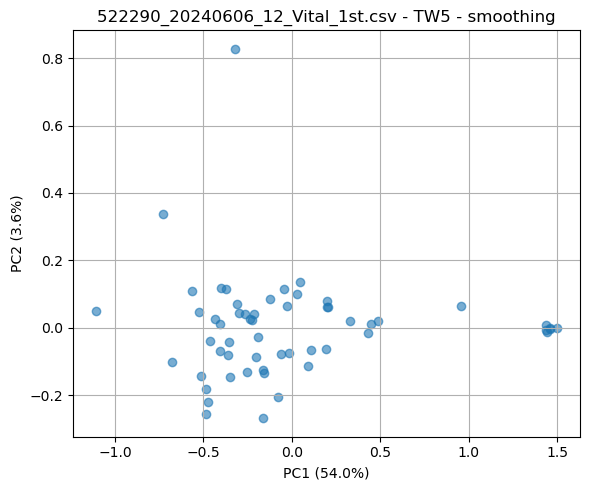

Explained variance for smoothing - TW5: PC1 = 0.5402, PC2 = 0.0356


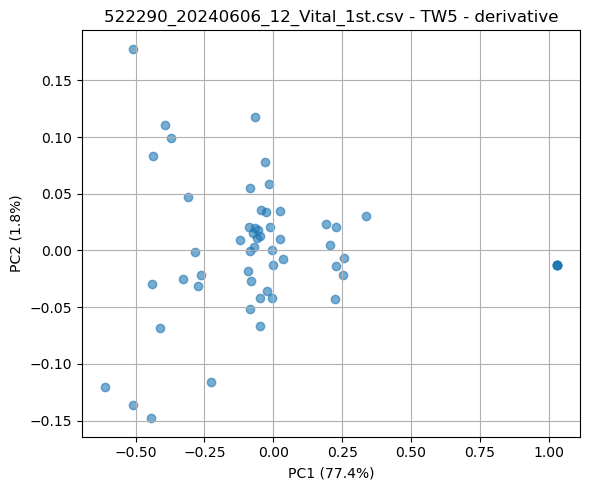

Explained variance for derivative - TW5: PC1 = 0.7740, PC2 = 0.0177


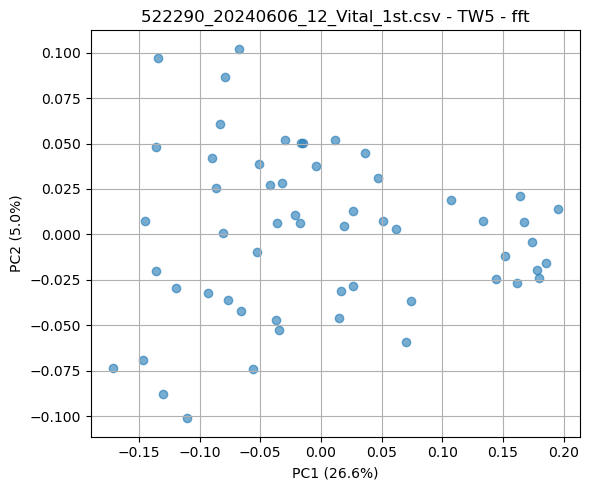

Explained variance for fft - TW5: PC1 = 0.2655, PC2 = 0.0498


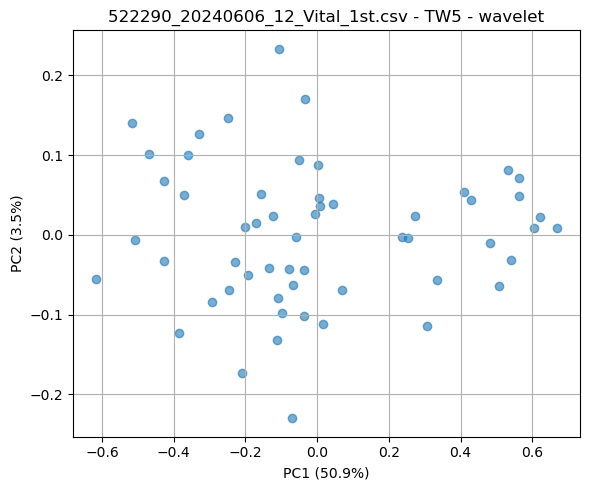

Explained variance for wavelet - TW5: PC1 = 0.5085, PC2 = 0.0346


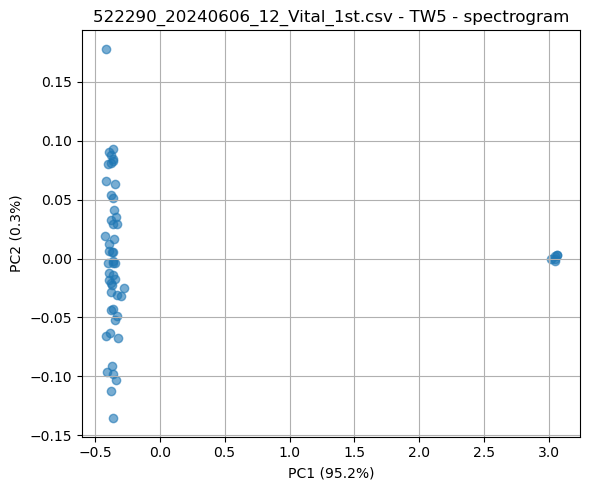

Explained variance for spectrogram - TW5: PC1 = 0.9522, PC2 = 0.0031


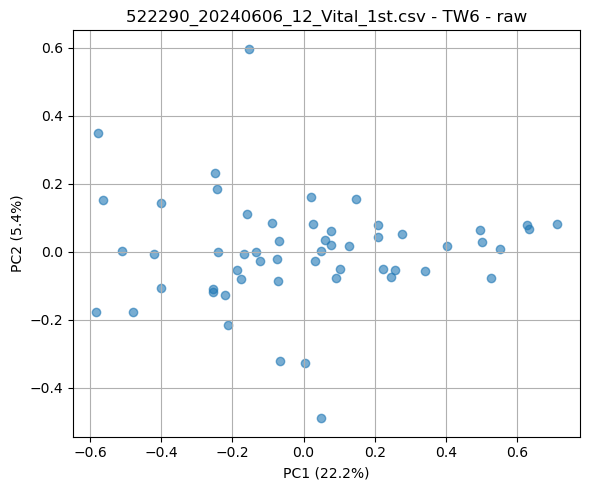

Explained variance for raw - TW6: PC1 = 0.2218, PC2 = 0.0544


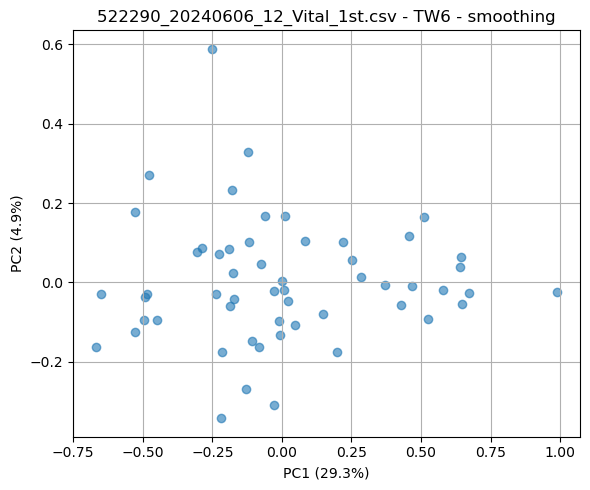

Explained variance for smoothing - TW6: PC1 = 0.2932, PC2 = 0.0491


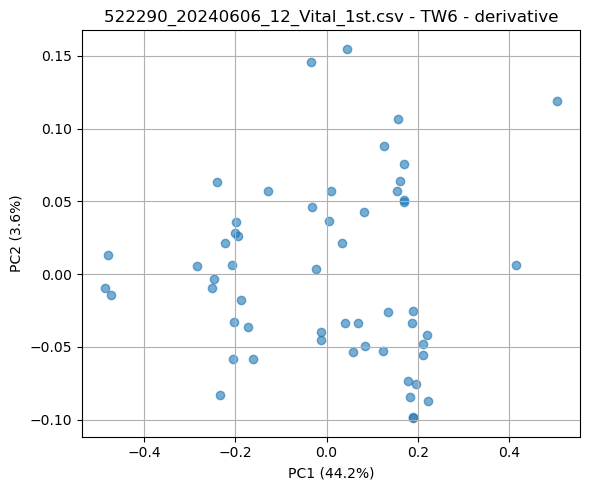

Explained variance for derivative - TW6: PC1 = 0.4425, PC2 = 0.0355


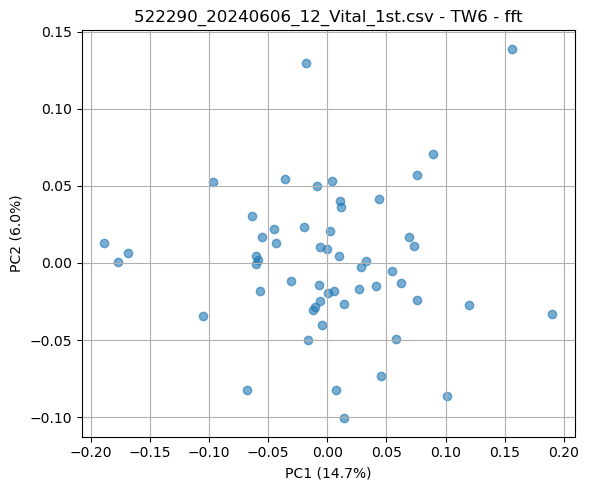

Explained variance for fft - TW6: PC1 = 0.1467, PC2 = 0.0598


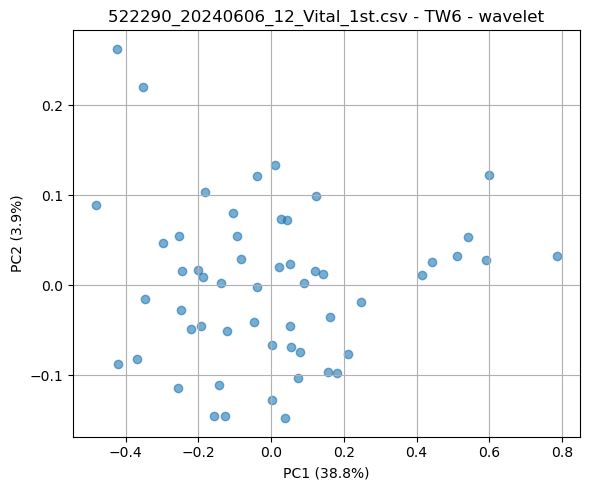

Explained variance for wavelet - TW6: PC1 = 0.3881, PC2 = 0.0385


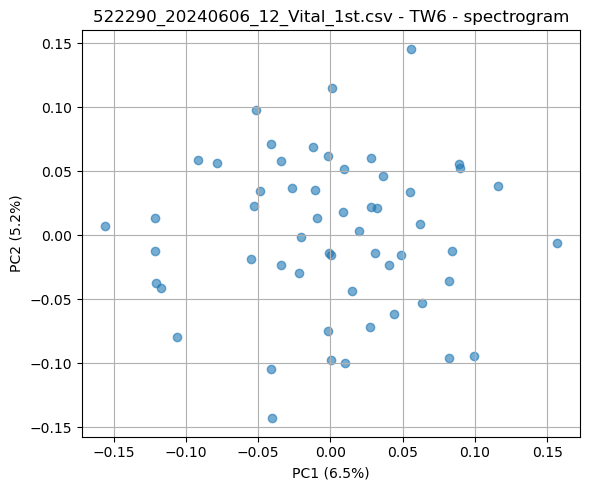

Explained variance for spectrogram - TW6: PC1 = 0.0647, PC2 = 0.0522


In [47]:
### Convolutional features (With signal processing)

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, spectrogram
from scipy.fftpack import fft
import pywt
from sklearn.decomposition import PCA

# === Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Path and signal name
## V1
signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st"
# signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st"

# === Signal names
signal_candidates = ["AVEA - PIP", "CDGR - PIP", "SVU - PIP"]
# signal_candidates = ["AVEA - PEEP", "CDGR - PEEP", "SVU - PEEP"]
# signal_candidates = ["TV (mL/Kg)"]
# signal_candidates = ["CDGR - Flow", "AVEA - Air Flow Wave", "SVU - Flow"]

## V2
# signal_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st"

# signal_candidates = ["CAPSULE_AVEAA_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_MAQUETC_VITAL_1414"]
# signal_candidates = ["CAPSULE_AVEAA_VITAL_1189", "CAPSULE_DRAGERMEDIBUS_VITAL_1189", "CAPSULE_MAQUETC_VITAL_1189"]
# signal_candidates = ["TV (mL/Kg)"]
# signal_candidates = ["CAPSULE_AVEAA_WAVE_52911", "CAPSULE_DRAGERMEDIBUS_WAVE_118", "MAQUET_CAPSULE_AIRWAY_FLOW_WAVE"]

# === Unit conversion
conversion_signals = {
    "CDGR - PIP", "CDGR - PEEP",
    "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_1189"
}
conversion_factor = 1.01972

chunk_size = 1024

# === 1D CNN Model
class SimpleCNN1D(nn.Module):
    def __init__(self):
        super(SimpleCNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x.view(x.size(0), -1)

# === Preprocessing
def preprocess_signal(signal, method, length=1024):
    if method == "raw":
        return signal
    elif method == "smoothing":
        return savgol_filter(signal, window_length=15, polyorder=2)
    elif method == "derivative":
        return np.gradient(signal)
    elif method == "fft":
        return np.abs(fft(signal))[:length]
    elif method == "wavelet":
        coeffs, _ = pywt.cwt(signal, scales=np.arange(1, 33), wavelet='morl')
        return np.mean(np.abs(coeffs), axis=0)[:length]
    elif method == "spectrogram":
        f, t, Sxx = spectrogram(signal, nperseg=64)
        return np.mean(Sxx, axis=0)[:length]
    else:
        raise ValueError("Unknown method")

# === Process files
for fname in os.listdir(signal_dir):
    if not fname.endswith(".csv"):
        continue

    df = pd.read_csv(os.path.join(signal_dir, fname))
    signal_name = next((col for col in signal_candidates if col in df.columns and df[col].notna().any()), None)
    if not signal_name:
        continue
    if signal_name in conversion_signals:
        df[signal_name] *= conversion_factor

    print(f"\n✅ Processing {fname} | Signal: {signal_name}")

    # Process each time window
    for tw in range(1, 7):
        df_tw = df[df['Tumbling_window'] == tw]
        if df_tw.empty or signal_name not in df_tw.columns:
            continue
        raw_signal = df_tw[signal_name].dropna().values.astype(np.float32)
        if len(raw_signal) < chunk_size:
            continue

        # Apply each preprocessing method on each chunk
        methods = ["raw", "smoothing", "derivative", "fft", "wavelet", "spectrogram"]
        method_features = {m: [] for m in methods}

        for start in range(0, len(raw_signal) - chunk_size + 1, chunk_size):
            segment = raw_signal[start:start+chunk_size]
            for method in methods:
                sig = preprocess_signal(segment.copy(), method, length=chunk_size)
                sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-6)
                tensor = torch.tensor(sig).view(1, 1, -1).float().to(device)
                model = SimpleCNN1D().to(device)
                with torch.no_grad():
                    feature = model(tensor).cpu().numpy().flatten()
                    method_features[method].append(feature)

        # PCA per method
        for method in methods:
            feats = np.stack(method_features[method])
            if feats.shape[0] < 2:
                continue
            pca = PCA(n_components=2)
            reduced = pca.fit_transform(feats)
            plt.figure(figsize=(6, 5))
            plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
            plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
            plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
            plt.title(f"{fname} - TW{tw} - {method}")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            print(f"Explained variance for {method} - TW{tw}: PC1 = {pca.explained_variance_ratio_[0]:.4f}, "
                  f"PC2 = {pca.explained_variance_ratio_[1]:.4f}")

    break  # remove this to process all files

Moving files

In [18]:
# import os
# import pandas as pd
# import shutil

# # === Load Sheet2 of the Excel file ===
# excel_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"
# df = pd.read_excel(excel_path, sheet_name="Sheet2")

# # === Filter rows where Cohort_Source is "V1" and filename is not null ===
# # df_v1 = df[(df["Cohort_Source"] == "V1") & df["FileName_V2_1st(V1_Vital_1st)"].notna()]
# # df_v1 = df[(df["Cohort_Source"] == "V1") & df["FileName_V1_Waveform_1st"].notna()]
# # df_v1 = df[(df["Cohort_Source"] == "V1") & df["FileName_V2_12th(V1_Vital_12th)"].notna()]
# df_v2 = df[(df["Cohort_Source"] == "V2") & df["FileName_V2_1st(V1_Vital_1st)"].notna()]
# # df_v2 = df[(df["Cohort_Source"] == "V2") & df["FileName_V2_12th(V1_Vital_12th)"].notna()]

# # === Set source and destination folders ===
# # src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st"
# # src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st/TV_V1_1st/Upsampled_V1_1st"
# # src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st"
# # src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V1/VitalData/02_Vital_Raw_226_12th/OSI_258_12th/TWs_258_12th"
# src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st"
# # src_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_12th_Raw/OSI_V2_12th/TWs_V2_12th"

# dst_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st"
# # dst_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_12th"

# os.makedirs(dst_dir, exist_ok=True)

# # === Copy matching CSV files ===
# copied = 0
# # for fname in df_v1["FileName_V2_1st(V1_Vital_1st)"]:
# # for fname in df_v1["FileName_V1_Waveform_1st"]:
# # for fname in df_v1["FileName_V2_12th(V1_Vital_12th)"]:
# for fname in df_v2["FileName_V2_1st(V1_Vital_1st)"]:
# # for fname in df_v2["FileName_V2_12th(V1_Vital_12th)"]:
#     src_path = os.path.join(src_dir, fname)
#     dst_path = os.path.join(dst_dir, fname)
#     if os.path.exists(src_path):
#         shutil.copy2(src_path, dst_path)
#         copied += 1
#     else:
#         print(f"⚠️ File not found: {src_path}")

# print(f"✅ Done. {copied} files copied to: {dst_dir}")


⚠️ File not found: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st/1133993_20240316_18_V2_1st_Raw.csv
⚠️ File not found: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st/21072_20240315_16_V2_1st_Raw.csv
⚠️ File not found: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V2_1st_Raw/OSI_V2_1st/TWs_V2_1st/PEEP_Settings_V2_1st/Abnormal_Deletion_V2_1st/TV_V2_1st/1134641_20240318_01_V2_1st_Raw.csv
✅ Done. 276 files copied to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st


### 1D-CNN (PIP, PEEP, TV, and Flow)

In [ ]:
# import os
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from glob import glob

# # === Set CUDA device ===
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("🔧 Using device:", device)

# # === CNN Model ===
# class Simple1DCNN(nn.Module):
#     def __init__(self):
#         super(Simple1DCNN, self).__init__()
#         self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
#         self.bn1 = nn.BatchNorm1d(16)
#         self.pool1 = nn.MaxPool1d(2)

#         self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
#         self.bn2 = nn.BatchNorm1d(32)
#         self.pool2 = nn.MaxPool1d(2)

#         self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm1d(64)
#         self.pool3 = nn.AdaptiveAvgPool1d(1)

#     def forward(self, x):
#         x = self.pool1(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool2(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool3(F.relu(self.bn3(self.conv3(x))))
#         return x.view(x.size(0), -1)

# # === Setup ===
# root_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st"
# cnn = Simple1DCNN().to(device).eval()

# conversion_signals = {
#     "CDGR - PIP", "CDGR - PEEP",
#     "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_1189"
# }
# conversion_factor = 1.01972

# vital_signals = {
#     "pip": ["AVEA - PIP", "CDGR - PIP", "SVU - PIP", "CAPSULE_AVEAA_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_MAQUETC_VITAL_1414"],
#     "peep": ["AVEA - PEEP", "CDGR - PEEP", "SVU - PEEP", "CAPSULE_AVEAA_VITAL_1189", "CAPSULE_DRAGERMEDIBUS_VITAL_1189", "CAPSULE_MAQUETC_VITAL_1189"],
#     "tv": ["TV (mL/Kg)"]
# }
# wave_signals = {
#     "flow": ["CDGR - Flow", "AVEA - Air Flow Wave", "SVU - Flow", "CAPSULE_AVEAA_WAVE_52911", "CAPSULE_DRAGERMEDIBUS_WAVE_118", "MAQUET_CAPSULE_AIRWAY_FLOW_WAVE"]
# }

# # === Extract signal with NaN-only row removal ===
# def extract_signal(df, candidates):
#     if df is None or df.empty:
#         return None
#     df_clean = df.dropna(how="all")  # Remove rows that are completely NaN
#     for c in candidates:
#         if c in df_clean.columns and df_clean[c].notna().any():
#             sig = df_clean[c].astype(float).dropna().values  # Drop NaNs within the column
#             if c in conversion_signals:
#                 sig *= conversion_factor
#             return sig
#     return None

# # === Gather Files ===
# all_files = glob(os.path.join(root_dir, "*.csv"))
# vital_files = [f for f in all_files if "Vital_1st" in f or "V2_1st_Raw" in f]
# wave_files = {
#     os.path.basename(f).replace("Waveform_1st.csv", "").replace("V2_1st_Raw.csv", ""): f
#     for f in all_files if "Waveform_1st" in f or "V2_1st_Raw" in f
# }

# # === Process Each Pair ===
# all_features = []

# for vital_path in vital_files:
#     base = os.path.basename(vital_path).replace("Vital_1st.csv", "").replace("V2_1st_Raw.csv", "")
#     wave_path = wave_files.get(base)

#     try:
#         df_vital = pd.read_csv(vital_path)
#         df_wave = pd.read_csv(wave_path) if wave_path else None

#         for tw in range(1, 7):  # Tumbling_window 1–6
#             features = []

#             df_v_tw = df_vital[df_vital["Tumbling_window"] == tw]
#             df_w_tw = df_wave[df_wave["Tumbling_window"] == tw] if df_wave is not None and "Tumbling_window" in df_wave.columns else None

#             for key in ["pip", "peep", "tv"]:
#                 sig = extract_signal(df_v_tw, vital_signals[key])
#                 if sig is not None and len(sig) >= 64:
#                     x = torch.tensor(sig, dtype=torch.float32).view(1, 1, -1).to(device)
#                     with torch.no_grad():
#                         feat = cnn(x).cpu().numpy().flatten()
#                     features.append(feat)
#                 else:
#                     features.append(np.zeros(64))

#             flow_sig = extract_signal(df_w_tw, wave_signals["flow"]) if df_w_tw is not None else None
#             if flow_sig is not None and len(flow_sig) >= 64:
#                 x = torch.tensor(flow_sig, dtype=torch.float32).view(1, 1, -1).to(device)
#                 with torch.no_grad():
#                     feat = cnn(x).cpu().numpy().flatten()
#                 features.append(feat)
#             else:
#                 features.append(np.zeros(64))

#             row_id = f"{base}_TW{tw}"
#             all_feat = np.concatenate(features)
#             all_features.append([row_id] + all_feat.tolist())
#             print(f"✅ Processed: {row_id}")

#     except Exception as e:
#         print(f"❌ Error processing {vital_path}: {e}")

# # === Save to Excel ===
# columns = ["PatientID"] + [f"f{i+1}" for i in range(256)]  # 4 signals × 64 features
# df_cnn = pd.DataFrame(all_features, columns=columns)
# output_path = os.path.join(root_dir, "CNN_Features_All.xlsx")
# df_cnn.to_excel(output_path, index=False)
# print("✅ CNN features saved to:", output_path)


🔧 Using device: cuda
✅ Processed: 522290_20240606_12__TW1
✅ Processed: 522290_20240606_12__TW2
✅ Processed: 522290_20240606_12__TW3
✅ Processed: 522290_20240606_12__TW4
✅ Processed: 522290_20240606_12__TW5
✅ Processed: 522290_20240606_12__TW6
✅ Processed: 1134621_20240418_17__TW1
✅ Processed: 1134621_20240418_17__TW2
✅ Processed: 1134621_20240418_17__TW3
✅ Processed: 1134621_20240418_17__TW4
✅ Processed: 1134621_20240418_17__TW5
✅ Processed: 1134621_20240418_17__TW6
✅ Processed: 875186_20231102_05__TW1
✅ Processed: 875186_20231102_05__TW2
✅ Processed: 875186_20231102_05__TW3
✅ Processed: 875186_20231102_05__TW4
✅ Processed: 875186_20231102_05__TW5
✅ Processed: 875186_20231102_05__TW6
✅ Processed: 228289_20240430_02__TW1
✅ Processed: 228289_20240430_02__TW2
✅ Processed: 228289_20240430_02__TW3
✅ Processed: 228289_20240430_02__TW4
✅ Processed: 228289_20240430_02__TW5
✅ Processed: 228289_20240430_02__TW6
✅ Processed: 58546_20230925_17__TW1
✅ Processed: 58546_20230925_17__TW2
✅ Processed: 

02/17/2026

============================================================

PURPOSE:
1) Make CNN weights deterministic (fixed seed)
2) Save CNN weights to a checkpoint file (state_dict)
3) (Optional) Save an md5 fingerprint so you can verify V3 uses same weights
4) Extract features exactly as before

============================================================

In [1]:
import os
import hashlib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from glob import glob

# === Set CUDA device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🔧 Using device:", device)

# === FIX randomness (IMPORTANT) ===
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Make cuDNN deterministic (slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# === CNN Model ===
class Simple1DCNN(nn.Module):
    def __init__(self):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x.view(x.size(0), -1)

# === Setup ===
root_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st"
os.makedirs(root_dir, exist_ok=True)

# Create CNN with deterministic init (due to fixed seeds above)
cnn = Simple1DCNN().to(device).eval()

# === SAVE CNN WEIGHTS (state_dict) ===
cnn_ckpt_path = os.path.join(root_dir, "Simple1DCNN_fixed_seed0_20260217.pt")
torch.save(cnn.state_dict(), cnn_ckpt_path)
print("✅ Saved CNN weights to:", cnn_ckpt_path)

# === Save a fingerprint (md5) so you can confirm V3 is using the SAME weights ===
def md5_of_file(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

cnn_md5 = md5_of_file(cnn_ckpt_path)
with open(os.path.join(root_dir, "Simple1DCNN_fixed_seed0_md5_20260217.txt"), "w") as f:
    f.write(cnn_md5 + "\n")
print("✅ CNN checkpoint MD5:", cnn_md5)

# ----------------------------
# The rest is your original pipeline (unchanged)
# ----------------------------
conversion_signals = {
    "CDGR - PIP", "CDGR - PEEP",
    "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_1189"
}
conversion_factor = 1.01972

vital_signals = {
    "pip": ["AVEA - PIP", "CDGR - PIP", "SVU - PIP", "CAPSULE_AVEAA_VITAL_2564", "CAPSULE_DRAGERMEDIBUS_VITAL_2564", "CAPSULE_MAQUETC_VITAL_1414"],
    "peep": ["AVEA - PEEP", "CDGR - PEEP", "SVU - PEEP", "CAPSULE_AVEAA_VITAL_1189", "CAPSULE_DRAGERMEDIBUS_VITAL_1189", "CAPSULE_MAQUETC_VITAL_1189"],
    "tv": ["TV (mL/Kg)"]
}
wave_signals = {
    "flow": ["CDGR - Flow", "AVEA - Air Flow Wave", "SVU - Flow", "CAPSULE_AVEAA_WAVE_52911", "CAPSULE_DRAGERMEDIBUS_WAVE_118", "MAQUET_CAPSULE_AIRWAY_FLOW_WAVE"]
}

# === Extract signal with NaN-only row removal ===
def extract_signal(df, candidates):
    if df is None or df.empty:
        return None
    df_clean = df.dropna(how="all")
    for c in candidates:
        if c in df_clean.columns and df_clean[c].notna().any():
            sig = pd.to_numeric(df_clean[c], errors="coerce").dropna().to_numpy(dtype=float)
            if sig.size == 0:
                continue
            if c in conversion_signals:
                sig = sig * conversion_factor
            return sig
    return None

# === Gather Files ===
all_files = glob(os.path.join(root_dir, "*.csv"))
vital_files = [f for f in all_files if "Vital_1st" in f or "V2_1st_Raw" in f]
wave_files = {
    os.path.basename(f).replace("Waveform_1st.csv", "").replace("V2_1st_Raw.csv", ""): f
    for f in all_files if "Waveform_1st" in f or "V2_1st_Raw" in f
}

# === Process Each Pair ===
all_features = []

for vital_path in vital_files:
    base = os.path.basename(vital_path).replace("Vital_1st.csv", "").replace("V2_1st_Raw.csv", "")
    wave_path = wave_files.get(base)

    try:
        df_vital = pd.read_csv(vital_path)
        df_wave = pd.read_csv(wave_path) if wave_path else None

        for tw in range(1, 7):
            features = []

            if "Tumbling_window" not in df_vital.columns:
                raise ValueError(f"Missing Tumbling_window in vital file: {vital_path}")

            df_v_tw = df_vital[df_vital["Tumbling_window"] == tw]
            df_w_tw = df_wave[df_wave["Tumbling_window"] == tw] if df_wave is not None and "Tumbling_window" in df_wave.columns else None

            for key in ["pip", "peep", "tv"]:
                sig = extract_signal(df_v_tw, vital_signals[key])
                if sig is not None and len(sig) >= 64:
                    x = torch.tensor(sig, dtype=torch.float32).view(1, 1, -1).to(device)
                    with torch.no_grad():
                        feat = cnn(x).cpu().numpy().flatten()
                    features.append(feat)
                else:
                    features.append(np.zeros(64, dtype=float))

            flow_sig = extract_signal(df_w_tw, wave_signals["flow"]) if df_w_tw is not None else None
            if flow_sig is not None and len(flow_sig) >= 64:
                x = torch.tensor(flow_sig, dtype=torch.float32).view(1, 1, -1).to(device)
                with torch.no_grad():
                    feat = cnn(x).cpu().numpy().flatten()
                features.append(feat)
            else:
                features.append(np.zeros(64, dtype=float))

            row_id = f"{base}_TW{tw}"
            all_feat = np.concatenate(features)  # 4 signals × 64 = 256
            all_features.append([row_id] + all_feat.tolist())
            print(f"✅ Processed: {row_id}")

    except Exception as e:
        print(f"❌ Error processing {vital_path}: {e}")

# === Save to Excel ===
columns = ["PatientID"] + [f"f{i+1}" for i in range(256)]
df_cnn = pd.DataFrame(all_features, columns=columns)
output_path = os.path.join(root_dir, "CNN_Features_All_20260217.xlsx")
df_cnn.to_excel(output_path, index=False)
print("✅ CNN features saved to:", output_path)

print("\nNEXT STEP (V3 script):")
print("Load this checkpoint before feature extraction:")
print("  cnn.load_state_dict(torch.load(r'{}', map_location=device))".format(cnn_ckpt_path))
print("And verify md5 matches:", cnn_md5)


🔧 Using device: cpu
✅ Saved CNN weights to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/Simple1DCNN_fixed_seed0_20260217.pt
✅ CNN checkpoint MD5: e488ca2bd62da22be2550ddfc3ad3ee3
✅ Processed: 522290_20240606_12__TW1
✅ Processed: 522290_20240606_12__TW2
✅ Processed: 522290_20240606_12__TW3
✅ Processed: 522290_20240606_12__TW4
✅ Processed: 522290_20240606_12__TW5
✅ Processed: 522290_20240606_12__TW6
✅ Processed: 1134621_20240418_17__TW1
✅ Processed: 1134621_20240418_17__TW2
✅ Processed: 1134621_20240418_17__TW3
✅ Processed: 1134621_20240418_17__TW4
✅ Processed: 1134621_20240418_17__TW5
✅ Processed: 1134621_20240418_17__TW6
✅ Processed: 875186_20231102_05__TW1
✅ Processed: 875186_20231102_05__TW2
✅ Processed: 875186_20231102_05__TW3
✅ Processed: 875186_20231102_05__TW4
✅ Processed: 875186_20231102_05__TW5
✅ Processed: 875186_20231102_05__TW6
✅ Processed: 228289_20240430_02__TW1
✅ Processed: 228289_20240430_02__TW2
✅ Processed: 228289_20240430_02_

### 1D-CNN (Flow)

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from glob import glob

# === Set CUDA device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🔧 Using device:", device)

# === CNN Model ===
class Simple1DCNN(nn.Module):
    def __init__(self):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x.view(x.size(0), -1)

# === Setup ===
root_dir = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st"
cnn = Simple1DCNN().to(device).eval()

# Only flow waveform signal candidates
wave_signals = {
    "flow": [
        "CDGR - Flow", "AVEA - Air Flow Wave", "SVU - Flow",
        "CAPSULE_AVEAA_WAVE_52911", "CAPSULE_DRAGERMEDIBUS_WAVE_118",
        "MAQUET_CAPSULE_AIRWAY_FLOW_WAVE"
    ]
}

# === Extract signal while removing empty rows and NaNs ===
def extract_signal(df, candidates):
    if df is None or df.empty:
        return None
    df_clean = df.dropna(how="all")  # remove fully empty rows
    for c in candidates:
        if c in df_clean.columns and df_clean[c].notna().any():
            sig = df_clean[c].astype(float).dropna().values  # drop NaNs within the column
            return sig
    return None

# === Gather Waveform Files Only ===
wave_files = [
    f for f in glob(os.path.join(root_dir, "*.csv"))
    if "Waveform_1st" in f or "V2_1st_Raw" in f
]

# === Process Each File ===
all_features = []

for wave_path in wave_files:
    base = os.path.basename(wave_path).replace("Waveform_1st.csv", "").replace("V2_1st_Raw.csv", "")

    try:
        df_wave = pd.read_csv(wave_path)
        if "Tumbling_window" not in df_wave.columns:
            print(f"⚠️ No Tumbling_window column in {wave_path}, skipping.")
            continue

        for tw in range(1, 7):  # Tumbling_window 1–6
            df_w_tw = df_wave[df_wave["Tumbling_window"] == tw]

            flow_sig = extract_signal(df_w_tw, wave_signals["flow"])
            if flow_sig is not None and len(flow_sig) >= 64:
                x = torch.tensor(flow_sig, dtype=torch.float32).view(1, 1, -1).to(device)
                with torch.no_grad():
                    feat = cnn(x).cpu().numpy().flatten()
            else:
                feat = np.zeros(64)

            row_id = f"{base}_TW{tw}"
            all_features.append([row_id] + feat.tolist())
            print(f"✅ Processed Flow: {row_id}")

    except Exception as e:
        print(f"❌ Error processing {wave_path}: {e}")

# === Save to Excel ===
columns = ["PatientID"] + [f"f{i+1}" for i in range(64)]  # Only Flow (64 features)
df_cnn = pd.DataFrame(all_features, columns=columns)
output_path = os.path.join(root_dir, "CNN_Features_FlowOnly.xlsx")
df_cnn.to_excel(output_path, index=False)
print("✅ Flow-only CNN features saved to:", output_path)


🔧 Using device: cuda
✅ Processed Flow: 1370607_20240831_00__TW1
✅ Processed Flow: 1370607_20240831_00__TW2
✅ Processed Flow: 1370607_20240831_00__TW3
✅ Processed Flow: 1370607_20240831_00__TW4
✅ Processed Flow: 1370607_20240831_00__TW5
✅ Processed Flow: 1370607_20240831_00__TW6
✅ Processed Flow: 606288_20240512_12__TW1
✅ Processed Flow: 606288_20240512_12__TW2
✅ Processed Flow: 606288_20240512_12__TW3
✅ Processed Flow: 606288_20240512_12__TW4
✅ Processed Flow: 606288_20240512_12__TW5
✅ Processed Flow: 606288_20240512_12__TW6
✅ Processed Flow: 1301993_20240904_06__TW1
✅ Processed Flow: 1301993_20240904_06__TW2
✅ Processed Flow: 1301993_20240904_06__TW3
✅ Processed Flow: 1301993_20240904_06__TW4
✅ Processed Flow: 1301993_20240904_06__TW5
✅ Processed Flow: 1301993_20240904_06__TW6
✅ Processed Flow: 1198474_20240501_01__TW1
✅ Processed Flow: 1198474_20240501_01__TW2
✅ Processed Flow: 1198474_20240501_01__TW3
✅ Processed Flow: 1198474_20240501_01__TW4
✅ Processed Flow: 1198474_20240501_01__

### Merge the CNN features to V1V2_df

In [6]:
import pandas as pd

# === Load the CNN feature file ===
# cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All.xlsx"
# cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_FlowOnly.xlsx"
cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All_20260217.xlsx"

df_cnn = pd.read_excel(cnn_feature_path, sheet_name="Sheet1")

# === Extract base PatientID (without _TWx) ===
df_cnn["BaseID"] = df_cnn["PatientID"].str.replace(r"_TW\d+$", "", regex=True)
df_cnn["Window"] = df_cnn["PatientID"].str.extract(r"_TW(\d)$")[0].astype(int)

# === Sort by BaseID and Tumbling Window ===
df_cnn = df_cnn.sort_values(by=["BaseID", "Window"])

# === Create wide-format dataframe ===
merged_rows = []
for base_id, group in df_cnn.groupby("BaseID"):
    group = group.sort_values("Window")
    
    # Only merge if all 6 windows are present
    if group.shape[0] != 6:
        print(f"⚠️ Skipping {base_id} — only {group.shape[0]} windows found.")
        continue

    feature_arrays = []
    for window in range(1, 7):
        row = group[group["Window"] == window]
        if row.empty:
            feature_arrays.extend([np.nan] * 256)
            # feature_arrays.extend([np.nan] * 64)
        else:
            feature_arrays.extend(row.iloc[0, 1:257].values)
            # feature_arrays.extend(row.iloc[0, 1:65].values)

    merged_rows.append([base_id] + feature_arrays)

# === Generate full column names: f1_TW1 to f256_TW6 ===
new_columns = ["PatientID"]
for tw in range(1, 7):
    new_columns.extend([f"f{i}_TW{tw}" for i in range(1, 257)])
    # new_columns.extend([f"f{i}_TW{tw}" for i in range(1, 65)])

# === Build final dataframe ===
final_df = pd.DataFrame(merged_rows, columns=new_columns)

# === Save to Excel ===
output_path = cnn_feature_path.replace(".xlsx", "_MergedByPatient_20260217.xlsx")
final_df.to_excel(output_path, index=False)
print("✅ Merged CNN features saved to:", output_path)


⚠️ Skipping 1011066_20231209_19_ — only 12 windows found.
⚠️ Skipping 1011066_20240521_16_ — only 12 windows found.
⚠️ Skipping 1018260_20231209_03_ — only 12 windows found.
⚠️ Skipping 1204199_20240502_12_ — only 12 windows found.
⚠️ Skipping 1223964_20240516_04_ — only 12 windows found.
⚠️ Skipping 1291078_20240705_17_ — only 12 windows found.
⚠️ Skipping 14627_20240127_10_ — only 12 windows found.
⚠️ Skipping 152774_20240207_22_ — only 12 windows found.
⚠️ Skipping 2294_20240520_17_ — only 12 windows found.
⚠️ Skipping 437225_20240215_15_ — only 12 windows found.
⚠️ Skipping 606288_20240512_12_ — only 12 windows found.
⚠️ Skipping 612715_20240209_12_ — only 12 windows found.
⚠️ Skipping 969268_20240713_01_ — only 12 windows found.
✅ Merged CNN features saved to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All_20260217_MergedByPatient_20260217.xlsx


In [7]:
import pandas as pd

# Load the CNN feature file
# cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All.xlsx"
# cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_FlowOnly.xlsx"
cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All_20260217_MergedByPatient_20260217.xlsx"

df_cnn = pd.read_excel(cnn_feature_path, sheet_name="Sheet1")

# Create MatchKey
df_cnn["MatchKey"] = df_cnn["PatientID"].str.rstrip("_")

# Find duplicated MatchKeys
duplicated_keys = df_cnn[df_cnn["MatchKey"].duplicated(keep=False)]

# Display duplicates
if not duplicated_keys.empty:
    print("⚠️ Found duplicate MatchKeys:")
    print(duplicated_keys.sort_values("MatchKey"))
else:
    print("✅ No duplicate MatchKeys found.")


✅ No duplicate MatchKeys found.


In [11]:
import re
import numpy as np
import pandas as pd

# === File paths ===
xlsx_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/PARDS_Risk_V1V2_df.xlsx"
cnn_feature_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V2/PARDS_Risk_RNN/V1V2_1st/CNN_Features_All_20260217_MergedByPatient_20260217.xlsx"

# === Load ===
df_v1v2 = pd.read_excel(xlsx_path, sheet_name="Sheet3")
df_cnn  = pd.read_excel(cnn_feature_path, sheet_name="Sheet1")

# ------------------------------------------------------------
# Build MatchKey
# ------------------------------------------------------------
key_pat = re.compile(r"(\d+_\d{8}_\d{2}_)")

def make_key(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    m = key_pat.search(s)
    return m.group(1) if m else np.nan

# From filename column
fname_col = "FileName_V2_1st(V1_Vital_1st)"
df_v1v2 = df_v1v2.copy()
df_v1v2["MatchKey"] = df_v1v2[fname_col].apply(make_key)

# From CNN PatientID
df_cnn = df_cnn.copy()
df_cnn["MatchKey"] = df_cnn["PatientID"].apply(make_key)

# ------------------------------------------------------------
# Identify CNN feature columns like f123_TW4
# ------------------------------------------------------------
feature_pattern = re.compile(r"^f\d+_TW\d+$")
cnn_feature_cols = [c for c in df_cnn.columns if feature_pattern.match(c)]

if len(cnn_feature_cols) == 0:
    raise ValueError("No CNN feature columns found like f*_TW*")

print(f"✅ Found {len(cnn_feature_cols)} CNN feature columns in df_cnn")

# Keep only necessary columns
df_cnn_sub = df_cnn[["MatchKey"] + cnn_feature_cols].copy()

# ------------------------------------------------------------
# Deduplicate per MatchKey
# ------------------------------------------------------------
def all_nan_features(row):
    return row[cnn_feature_cols].isna().all()

clean_rows = []
for mk, g in df_cnn_sub.groupby("MatchKey", dropna=False):
    if pd.isna(mk):
        continue
    g_non_nan = g[~g.apply(all_nan_features, axis=1)]
    clean_rows.append(g_non_nan.iloc[0] if len(g_non_nan) else g.iloc[0])

df_cnn_clean = pd.DataFrame(clean_rows).set_index("MatchKey")

# ------------------------------------------------------------
# Align features to Sheet3 row order
# ------------------------------------------------------------
new_feat = []

for mk in df_v1v2["MatchKey"].tolist():
    if pd.isna(mk) or mk not in df_cnn_clean.index:
        new_feat.append([np.nan] * len(cnn_feature_cols))
    else:
        new_feat.append(df_cnn_clean.loc[mk, cnn_feature_cols].to_numpy())

df_feat = pd.DataFrame(new_feat, columns=cnn_feature_cols)

# ------------------------------------------------------------
# SUBSTITUTE old CNN features in Sheet3-copy
# ------------------------------------------------------------
existing_cols = [c for c in cnn_feature_cols if c in df_v1v2.columns]

if existing_cols:
    print(f"🔁 Replacing {len(existing_cols)} existing CNN feature columns")
    df_v1v2_no_old = df_v1v2.drop(columns=existing_cols)
else:
    df_v1v2_no_old = df_v1v2

df_sheet5 = pd.concat([df_v1v2_no_old, df_feat], axis=1)

# ------------------------------------------------------------
# Save as Sheet5 (Sheet3 untouched)
# ------------------------------------------------------------
with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_sheet5.to_excel(writer, sheet_name="Sheet5", index=False)

print("✅ Sheet5 created with substituted CNN features (f*_TW*).")


✅ Found 1536 CNN feature columns in df_cnn
🔁 Replacing 1536 existing CNN feature columns
✅ Sheet5 created with substituted CNN features (f*_TW*).
